In [1]:
from erebus.individual_fit_results import IndividualFitResults
from erebus.joint_fit_results import JointFitResults
import numpy as np
from glob import glob
import os
from uncertainties import ufloat
import yaml
import matplotlib.pyplot as plt
import matplotlib
from matplotlib import cm
from matplotlib import colors as colours
from scipy.stats import norm
from erebus.utility.utils import bin_data
from erebus.utility.utils import get_eclipse_duration

plt.rcParams.update({
    'font.size': 14
})

In [5]:
joint_fit = JointFitResults.load(glob("./*/*joint*.h5")[0])
print(joint_fit.results)

2026-03-26 10:47:54,078 - stpipe - WARNING - /home/nicho/.local/lib/python3.11/site-packages/uncertainties/core.py:1024: UserWarning: Using UFloat objects with std_dev==0 may give unexpected results.
  warn("Using UFloat objects with std_dev==0 may give unexpected results.")



{'fp': 0.00013707272346412706+/-2.27987311358447e-05, 'rp_rstar': 0.03180309963768438+/-0.000697721334506584, 'a_rstar': 17.14900318848104+/-0.39414696564677953, 'p': 2.6162644+/-0, 'inc': 89.19001167861478+/-0.5511313421268937, 'esinw': 0.0+/-0, 'ecosw': 0.0+/-0, 't_sec_offset': 0.0+/-0, 't_sec_offset_0': -0.03352594910200259+/-0.0069161060158302624, 't_sec_offset_1': -0.03957155421754976+/-0.003052762446072728, 't_sec_offset_2': -0.014868281262206554+/-0.003357207604351576, 't_sec_offset_3': -0.000579064480834636+/-0.012863893403151331, 'fp_0': 0.0+/-0, 'fp_1': 0.0+/-0, 'fp_2': 0.0+/-0, 'fp_3': 0.0+/-0, 'pc1_0': 0.0+/-0, 'pc2_0': 0.0+/-0, 'pc3_0': 0.0+/-0, 'pc4_0': 0.0+/-0, 'pc5_0': 0.0+/-0, 'exp1_0': 0.0+/-0, 'exp2_0': 0.0+/-0, 'a_0': -0.01011920239252052+/-0.0006860685995568657, 'b_0': 0.0012677717180067938+/-8.808585368067607e-05, 'obs1_pc1_0': -0.53371914399376+/-0.08581876304824196, 'obs1_pc2_0': -0.883213209992737+/-0.19789371633299385, 'obs1_pc3_0': -0.8521779029712115+/-0.196

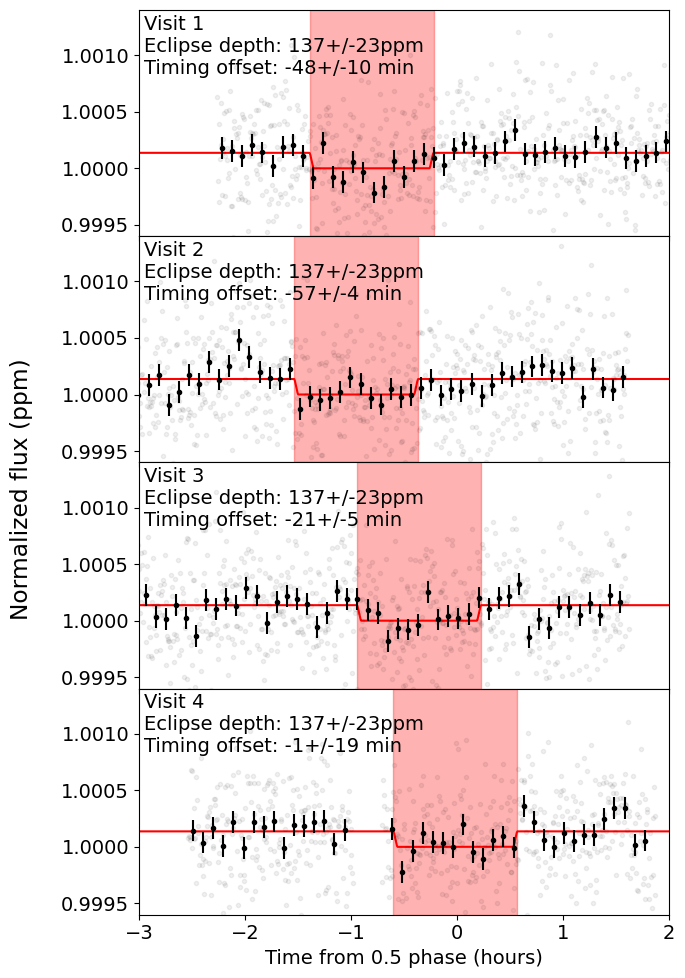

In [31]:
fig, axs = plt.subplots(4, 1, figsize=(7, 10), sharey='col', sharex='col')

def get_eclipse_duration_from_res(visit):
	return get_eclipse_duration(
		visit.results['inc'].nominal_value,
		visit.results['a_rstar'].nominal_value,
		visit.results['rp_rstar'].nominal_value,
		visit.results['p'].nominal_value
	) * 24

def plot_individual(visit, i, visit_index):	
	ax = axs[i]
	
	yerr = visit.results['y_err'].nominal_value
	fp = visit.results['fp'].nominal_value
	fp_err = visit.results['fp'].std_dev

	duration = get_eclipse_duration_from_res(visit)

	# Joint fit
	bin_size = 15
	time = visit.time_per_visit[i]
	flux = visit.detrended_flux_per_visit[i]
	flux = flux[np.argsort(time)]
	time = np.sort(time)
	time = time[~np.isnan(time)]
	flux = flux[~np.isnan(flux)]
	
	model_time = time
	model = visit.model_flux_per_visit[i]
	model = model[np.argsort(model_time)]
	model_time = np.sort(model_time)
	model = model[~np.isnan(model)]
	model_time = model_time[~np.isnan(model_time)]

	binned_time, _ = bin_data(time, bin_size)
	binned_flux, _ = bin_data(flux, bin_size)

	t_sec = visit.results[f't_sec_offset_{i}'].nominal_value * 24
	model_time += t_sec

	model_time = np.append(model_time, 3)
	model = np.append(model, model[-1])
	model_time[0] = -3
	
	ax.plot(model_time, model, color='red')
	
	ax.plot(time, flux, marker='.', linestyle='', alpha=0.06, color='black')

	if visit_index == 4:
		binned_time = np.delete(binned_time, 16)
		binned_flux = np.delete(binned_flux, 16)
	ax.errorbar(binned_time, binned_flux, yerr=yerr / np.sqrt(bin_size), linestyle='', marker='.', color='black')
	ax.axvspan(t_sec - duration / 2.0, t_sec + duration / 2.0, color='red', alpha=0.3)

	display_text = f"Visit {visit_index}"
	display_text += f"\nEclipse depth: {fp*1e6:.0f}+/-{fp_err*1e6:.0f}ppm"
	bin_size = 1 if visit_index >= 0 else 4
	t_sec_offset = visit.results[f't_sec_offset_{i}'] * 24 * 60
	display_text += f"\nTiming offset: {t_sec_offset.nominal_value:.0f}+/-{t_sec_offset.std_dev:.0f} min"
	ax.text(0.01, 0.98, display_text, horizontalalignment='left', verticalalignment='top', transform=ax.transAxes, fontsize=14)

plot_individual(joint_fit, 0, 1)
plot_individual(joint_fit, 1, 2)
plot_individual(joint_fit, 2, 3)
plot_individual(joint_fit, 3, 4)

for ax in axs:
	ax.set_ylim([0.9994, 1.0014])
	ax.set_yticks([0.9995, 1, 1.0005, 1.001])
	ax.set_yticklabels([0.9995, '1.0000', 1.0005, '1.0010'])
	#ax.set_xlim([-3, 2])

fig.supylabel("Normalized flux (ppm)")
axs[-1].set_xlabel("Time from 0.5 phase (hours)")
plt.xlim([-3, 2])

plt.tight_layout()
plt.subplots_adjust(hspace=0, wspace=0.2)
plt.savefig("variable_t_sec.png", bbox_inches='tight')
#plt.savefig("figures/old_combined_results.pdf", bbox_inches='tight')
plt.show()

In [48]:
other_bic = -39224.82298276646
variable_t_sec_bic = joint_fit.BIC 

m = np.min([other_bic, variable_t_sec_bic])

print(other_bic - m)
print(variable_t_sec_bic - m)

0.0
5.839278145074786
